In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Training model...

Model Performance:
Accuracy: 96.49%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



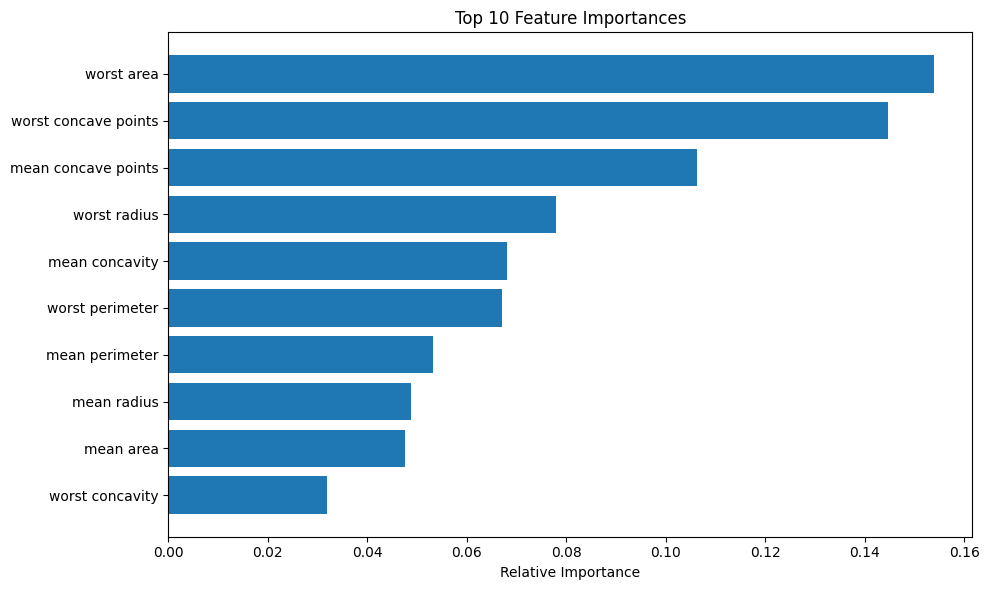

Model exported to 'tumor_model.pkl'

Test Prediction for first record: Benign


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def prepare_data():
    """Loads and splits the breast cancer dataset."""
    raw_data = load_breast_cancer()
    X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
    y = raw_data.target
    
    return train_test_split(X, y, test_size=0.2, random_state=42), raw_data.target_names

def train_forest(X_train, y_train):
    """Initializes and trains the Random Forest model."""
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    return rf

def plot_importance(model, feature_names, top_n=10):
    """Visualizes the most influential features."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.title(f"Top {top_n} Feature Importances")
    plt.barh(range(len(indices)), importances[indices], align="center")
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()

def get_prediction_label(model, sample_data):
    """Returns a human-readable string for a prediction."""
    # Ensure data is 2D for the model
    data_reshaped = np.array(sample_data).reshape(1, -1)
    prediction = model.predict(data_reshaped)[0]
    return "Malignant" if prediction == 0 else "Benign"

def main():
    # 1. Setup
    (X_train, X_test, y_train, y_test), target_names = prepare_data()
    
    # 2. Training
    print("Training model...")
    model = train_forest(X_train, y_train)
    
    # 3. Evaluation
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f"\nModel Performance:")
    print(f"Accuracy: {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=target_names))
    
    # 4. Feature Analysis
    plot_importance(model, X_train.columns)
    
    # 5. Persistence
    joblib.dump(model, 'tumor_model.pkl')
    print("Model exported to 'tumor_model.pkl'")

    # 6. Sanity Check
    example_sample = X_test.iloc[0].values
    result = get_prediction_label(model, example_sample)
    print(f"\nTest Prediction for first record: {result}")

if __name__ == "__main__":
    main()